In [50]:
import sqlite3
import pandas as pd

db_file = '/content/noshow (4).db'

# Connect to the SQLite database
conn = sqlite3.connect(db_file)
cursor = conn.cursor()

print(f"Successfully connected to database: {db_file}")

Successfully connected to database: /content/noshow (4).db


### Listing Tables in the Database

First, let's see what tables are available in this database.

In [64]:
# Get a list of all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

if tables:
    print("Tables found in the database:")
    for table in tables:
        print(f"- {table[0]}")
else:
    print("No tables found in the database.")

# Store table names in a list for later use
table_names = [table[0] for table in tables]

Tables found in the database:
- noshow


### Exploring the First Table

Let's take a look at the first table to understand its structure and content.

In [65]:
if table_names:
    first_table = table_names[0]
    print(f"Loading the full dataset from table: '{first_table}'")

    # Re-establish connection as it was closed
    conn = sqlite3.connect(db_file)

    # Read the entire table into a pandas DataFrame
    df = pd.read_sql_query(f"SELECT * FROM {first_table};", conn)
    display(df.head())
    print(f"Total rows loaded: {len(df)}")
else:
    print("No tables to explore.")

# Close the connection
conn.close()
print("Database connection closed.")

Loading the full dataset from table: 'noshow'


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0.0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0
1,86543,0.0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0
2,75928,0.0,Changi,March,February,7.0,February,11.0,India,Yes,Single,None,Agent,1,0.0
3,66947,1.0,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0
4,106390,0.0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0


Total rows loaded: 119391
Database connection closed.


### Data Exploration: Initial Overview

In [66]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119391 entries, 0 to 119390
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   booking_id      119391 non-null  int64  
 1   no_show         119390 non-null  float64
 2   branch          119390 non-null  object 
 3   booking_month   119390 non-null  object 
 4   arrival_month   119390 non-null  object 
 5   arrival_day     119390 non-null  float64
 6   checkout_month  119390 non-null  object 
 7   checkout_day    119390 non-null  float64
 8   country         119390 non-null  object 
 9   first_time      119390 non-null  object 
 10  room            97778 non-null   object 
 11  price           94509 non-null   object 
 12  platform        119390 non-null  object 
 13  num_adults      119390 non-null  object 
 14  num_children    119390 non-null  float64
dtypes: float64(4), int64(1), object(10)
memory usage: 13.7+ MB


### Descriptive Statistics for Numerical Columns

In [67]:
# Display descriptive statistics for numerical columns
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,booking_id,no_show,arrival_day,checkout_day,num_children
count,119391.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,59695.000000,0.370416,15.798241,14.250507,0.871229
std,34465.357332,0.482918,8.780829,11.063697,0.779796
min,0.000000,0.000000,1.000000,-31.000000,0.000000
25%,29847.500000,0.000000,8.000000,7.000000,0.000000
50%,59695.000000,0.000000,16.000000,15.000000,1.000000
75%,89542.500000,1.000000,23.000000,23.000000,1.000000
max,119390.000000,1.000000,31.000000,31.000000,3.000000


### Checking for Missing Values

In [68]:
# Check for missing values
print("Missing Values (Sum per Column):")
display(df.isnull().sum())

Missing Values (Sum per Column):


,0
booking_id,0
no_show,1
branch,1
booking_month,1
arrival_month,1
arrival_day,1
checkout_month,1
checkout_day,1
country,1
first_time,1


### Examining Unique Values in Categorical Columns

In [69]:
# Examine unique values and their counts for object type columns
print("Unique Values and Counts for Categorical Columns:")
for column in df.select_dtypes(include='object').columns:
    print(f"\n--- Column: {column} ---")
    # Display value counts if there are a reasonable number of unique values
    if df[column].nunique() < 50:
        display(df[column].value_counts())
    else:
        # Otherwise, just print the number of unique values
        print(f"Number of unique values: {df[column].nunique()}")

Unique Values and Counts for Categorical Columns:

--- Column: branch ---


,count
branch,
Changi,79330
Orchard,40060



--- Column: booking_month ---


,count
booking_month,
June,10324
September,10315
November,10280
January,10214
August,10134
October,10068
July,9993
March,9754
February,9588



--- Column: arrival_month ---
Number of unique values: 88

--- Column: checkout_month ---


...

,count
room,
King,70496
Single,15697
Queen,10824
President Suite,761



--- Column: price ---
Number of unique values: 61867

--- Column: platform ---


,count
platform,
Website,54234
Email,32608
Agent,21735
Phone,10813



--- Column: num_adults ---


,count
num_adults,
1,62745
2,45243
one,6334
two,5068


### Data Cleaning: Initial Steps

Based on the initial exploration, let's proceed with some cleaning steps. This might include:
- Renaming columns for clarity.
- Converting data types (e.g., `booking_id` to integer).
- Handling the `no_show` column, which seems to be a target variable and currently float.
- Addressing columns like `deposit_type`, `customer_type`, `required_car_parking_spaces` based on their unique values.

In [70]:
df


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children
0,94113,0.0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0
1,86543,0.0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0
2,75928,0.0,Changi,March,February,7.0,February,11.0,India,Yes,Single,None,Agent,1,0.0
3,66947,1.0,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0
4,106390,0.0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119386,4823,0.0,Changi,September,April,3.0,April,5.0,China,Yes,King,USD$ 612.18,Website,1,1.0
119387,25062,0.0,Orchard,March,December,30.0,January,3.0,China,Yes,King,USD$ 1041.29,Email,2,0.0
119388,81936,1.0,Changi,September,March,31.0,April,1.0,Indonesia,Yes,King,USD$ 641.47,Email,1,2.0
119389,6738,0.0,Changi,February,February,25.0,February,27.0,China,Yes,None,SGD$ 886.35,Website,2,0.0


In [71]:
# Rename columns for better readability (example based on common dataset conventions)
df = df.rename(columns={
    'booking_id': 'BookingID',
    'no_show': 'NoShow',
    'branch': 'Branch',
    'booking_month': 'BookingMonth',
    'arrival_month': 'ArrivalMonth',
    'room': 'RoomType',
    'deposit_type': 'DepositType',
    'customer_type': 'CustomerType',
    'required_car_parking_spaces': 'RequiredParkingSpaces',
    'total_of_special_requests': 'TotalSpecialRequests'
})


### Data Cleaning Step 1: Handling the `price` field

The `price` field is currently a text type, mixes 'SGD$' and 'USD$' prefixes, and has about 21% missing values. I will:
1. Convert all prices to SGD using a placeholder exchange rate (1 USD = 1.35 SGD).
2. Remove currency symbols and convert to numeric.
3. Impute the missing values with the median price after conversion.

In [72]:
df.columns

Index(['BookingID', 'NoShow', 'Branch', 'BookingMonth', 'ArrivalMonth',
       'arrival_day', 'checkout_month', 'checkout_day', 'country',
       'first_time', 'RoomType', 'price', 'platform', 'num_adults',
       'num_children'],
      dtype='object')

In [73]:
# Placeholder exchange rate (1 USD = 1.35 SGD)
USD_TO_SGD_EXCHANGE_RATE = 1.35

# Clean and convert 'price' column
def clean_price(price_str):
    if pd.isna(price_str):
        return None
    price_str = str(price_str).strip()
    if price_str.startswith('SGD$'):
        return float(price_str.replace('SGD$', ''))
    elif price_str.startswith('USD$'):
        usd_price = float(price_str.replace('USD$', ''))
        return usd_price * USD_TO_SGD_EXCHANGE_RATE
    return None # Handle cases that don't match prefixes

df['Price_SGD'] = df['price'].apply(clean_price)

# Impute missing values with the median of 'Price_SGD' grouped by 'ArrivalMonth'
df['Price_SGD'] = df.groupby('ArrivalMonth')['Price_SGD'].transform(lambda x: x.fillna(x.median()))

print("Price distribution after cleaning and conversion to SGD:")
display(df[['price', 'Price_SGD']].head())
print(f"Number of missing values in Price_SGD after imputation: {df['Price_SGD'].isnull().sum()}")

Price distribution after cleaning and conversion to SGD:


,price,Price_SGD
0,SGD$ 492.98,492.9800
1,SGD$ 1351.22,1351.2200
2,None,923.4540
3,SGD$ 666.04,666.0400
4,USD$ 665.37,898.2495


Number of missing values in Price_SGD after imputation: 2


In [74]:
df['Price_SGD']

,Price_SGD
0,492.9800
1,1351.2200
2,923.4540
3,666.0400
4,898.2495
...,...
119386,826.4430
119387,1405.7415
119388,865.9845
119389,886.3500


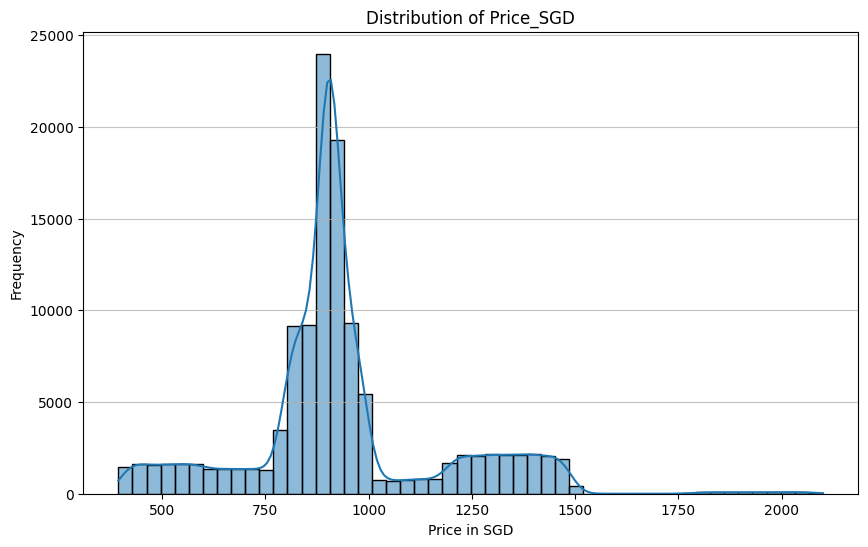

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Price_SGD'].dropna(), kde=True, bins=50)
plt.title('Distribution of Price_SGD')
plt.xlabel('Price in SGD')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Data Cleaning Step 2: Standardizing the `num_adults` field

The `num_adults` field contains both numeric strings ('1', '2') and English words ('one', 'two'). I will convert all entries to numerical format.

In [76]:
# Standardize 'num_adults'
num_adults_mapping = {
    'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6,
    'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
    '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10
}

# Convert to string first to handle both int and string types consistently
df['NumAdults'] = df['num_adults'].astype(str).str.lower().map(num_adults_mapping)

# Convert to integer type, coercing errors to NaN
df['NumAdults'] = pd.to_numeric(df['NumAdults'], errors='coerce')

# Handle any new NaNs that might have been introduced by non-matching values (e.g., impute with mode or 0)
# For now, let's assume valid values or impute with 0 if non-guests are expected
df['NumAdults'].fillna(0, inplace=True) # Assuming 0 adults for unparseable entries
df['NumAdults'] = df['NumAdults'].astype(int)

print("Unique values in NumAdults after standardization:")
display(df['NumAdults'].value_counts())
print(f"Number of missing values in NumAdults after cleaning: {df['NumAdults'].isnull().sum()}")

Unique values in NumAdults after standardization:


/tmp/ipykernel_1490/1926284077.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NumAdults'].fillna(0, inplace=True) # Assuming 0 adults for unparseable entries


,count
NumAdults,
1,69079
2,50311
0,1


Number of missing values in NumAdults after cleaning: 0


### Data Cleaning Step 3: Normalizing the `ArrivalMonth` field

The `ArrivalMonth` field has inconsistent capitalization, leading to 88 unique entries. I will normalize them to a consistent format (e.g., title case).

In [77]:
# Normalize 'ArrivalMonth' to title case
df['ArrivalMonth'] = df['ArrivalMonth'].astype(str).str.title()

print("Unique values in ArrivalMonth after normalization:")
display(df['ArrivalMonth'].value_counts())
print(f"Number of unique values in ArrivalMonth: {df['ArrivalMonth'].nunique()}")

Unique values in ArrivalMonth after normalization:


,count
ArrivalMonth,
August,13877
July,12661
May,11791
October,11160
April,11089
June,10939
September,10508
March,9794
February,8068


Number of unique values in ArrivalMonth: 13


### Data Cleaning Step 4: Correcting `checkout_day`

The `checkout_day` field contains negative values, indicating data entry errors. I will replace these with `NaN` for now and later decide on a proper imputation or removal strategy. Given it's a day, a value of 1-31 is expected.

In [80]:
# Convert 'checkout_day' to numeric, coercing errors, then handle negative values
df['CheckoutDay'] = pd.to_numeric(df['checkout_day'], errors='coerce')

# Replace negative values with their absolute value as requested
df.loc[df['CheckoutDay'] < 0, 'CheckoutDay'] = df.loc[df['CheckoutDay'] < 0, 'CheckoutDay'].abs()

print("Statistics for CheckoutDay after handling negative values:")
display(df['CheckoutDay'].describe())
print(f"Number of missing values in CheckoutDay after cleaning: {df['CheckoutDay'].isnull().sum()}")

Statistics for CheckoutDay after handling negative values:


,CheckoutDay
count,119390.000000
mean,15.763247
std,8.775079
min,1.000000
25%,8.000000
50%,16.000000
75%,23.000000
max,31.000000


Number of missing values in CheckoutDay after cleaning: 1


In [ ]:
print("Value counts for CheckoutDay after handling negative values:")
display(df['CheckoutDay'].value_counts())

In [81]:
print(df['CheckoutDay'].value_counts())

CheckoutDay
11.0    4656
18.0    4468
20.0    4434
27.0    4221
4.0     4175
6.0     4147
17.0    4139
28.0    4116
1.0     4071
25.0    3992
19.0    3991
14.0    3983
22.0    3970
21.0    3937
29.0    3881
7.0     3874
26.0    3815
3.0     3794
16.0    3789
5.0     3786
15.0    3763
8.0     3722
10.0    3692
24.0    3675
13.0    3651
2.0     3647
9.0     3639
23.0    3469
12.0    3465
30.0    3262
31.0    2166
Name: count, dtype: int64


### Data Cleaning Step 5: Handling Missing Values in `RoomType` and the All-Missing Row

The `RoomType` field has about 18% missing values. I will remove these rows as they might be crucial for analysis. Also, there's one entirely missing row that needs to be removed.

In [82]:
initial_rows = len(df)

# Remove rows where 'RoomType' is missing
df.dropna(subset=['RoomType'], inplace=True)
print(f"Rows removed due to missing RoomType: {initial_rows - len(df)}")
initial_rows = len(df)

# Remove the single row where all values are missing (if it still exists)
df.dropna(how='all', inplace=True)
print(f"Rows removed due to all missing values: {initial_rows - len(df)}")

print(f"Total rows after RoomType and all-missing row cleaning: {len(df)}")
print(f"Missing values in RoomType after cleaning: {df['RoomType'].isnull().sum()}")

Rows removed due to missing RoomType: 21613
Rows removed due to all missing values: 0
Total rows after RoomType and all-missing row cleaning: 97778
Missing values in RoomType after cleaning: 0


### Data Cleaning Step 6: Handling Missing Values in `NoShow` Target Variable

The `NoShow` target variable has one missing value. Since it's the target, it's generally best to remove rows with missing target values.

In [83]:
initial_rows = len(df)

# Remove rows where 'NoShow' is missing
df.dropna(subset=['NoShow'], inplace=True)

print(f"Rows removed due to missing NoShow: {initial_rows - len(df)}")
print(f"Missing values in NoShow after cleaning: {df['NoShow'].isnull().sum()}")
print(f"Final number of rows after all cleaning steps: {len(df)}")

# Display final info and head to verify changes
print("\nDataFrame Info after all cleaning steps:")
df.info()


# Convert 'NoShow' to integer type, as it likely represents a binary 0/1
df['NoShow'] = df['NoShow'].astype(int)

# Convert 'BookingID' to integer type
df['BookingID'] = df['BookingID'].astype(int)

# Display the DataFrame info after cleaning
print("DataFrame Info after initial cleaning:")
df.info()

# Display the first few rows with new column names
print("DataFrame head after column renaming and type conversion:")
display(df.head())

print("\nDataFrame head after all cleaning steps:")
display(df.head())

Rows removed due to missing NoShow: 0
Missing values in NoShow after cleaning: 0
Final number of rows after all cleaning steps: 97778

DataFrame Info after all cleaning steps:
<class 'pandas.core.frame.DataFrame'>
Index: 97778 entries, 0 to 119390
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BookingID       97778 non-null  int64  
 1   NoShow          97778 non-null  float64
 2   Branch          97778 non-null  object 
 3   BookingMonth    97778 non-null  object 
 4   ArrivalMonth    97778 non-null  object 
 5   arrival_day     97778 non-null  float64
 6   checkout_month  97778 non-null  object 
 7   checkout_day    97778 non-null  float64
 8   country         97778 non-null  object 
 9   first_time      97778 non-null  object 
 10  RoomType        97778 non-null  object 
 11  price           72897 non-null  object 
 12  platform        97778 non-null  object 
 13  num_adults      97778 non-null  object 

,BookingID,NoShow,Branch,BookingMonth,ArrivalMonth,arrival_day,checkout_month,checkout_day,country,first_time,RoomType,price,platform,num_adults,num_children,Price_SGD,NumAdults,CheckoutDay
0,94113,0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0,492.9800,1,27.0
1,86543,0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0,1351.2200,2,29.0
2,75928,0,Changi,March,February,7.0,February,11.0,India,Yes,Single,None,Agent,1,0.0,923.4540,1,11.0
3,66947,1,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0,666.0400,1,3.0
4,106390,0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0,898.2495,1,24.0



DataFrame head after all cleaning steps:


,BookingID,NoShow,Branch,BookingMonth,ArrivalMonth,arrival_day,checkout_month,checkout_day,country,first_time,RoomType,price,platform,num_adults,num_children,Price_SGD,NumAdults,CheckoutDay
0,94113,0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0,492.9800,1,27.0
1,86543,0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0,1351.2200,2,29.0
2,75928,0,Changi,March,February,7.0,February,11.0,India,Yes,Single,None,Agent,1,0.0,923.4540,1,11.0
3,66947,1,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0,666.0400,1,3.0
4,106390,0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0,898.2495,1,24.0


In [84]:
# Save the cleaned DataFrame to a CSV file
output_csv_path = 'cleaned_noshow_data.csv'
df.to_csv(output_csv_path, index=False)

print(f"Cleaned data saved successfully to {output_csv_path}")

Cleaned data saved successfully to cleaned_noshow_data.csv


In [85]:
import pandas as pd

# Read the cleaned CSV file back into a DataFrame
cleaned_df = pd.read_csv('cleaned_noshow_data.csv')

# Display the first few rows of the newly loaded DataFrame to verify
print("First 5 rows of the loaded 'cleaned_noshow_data.csv':")
display(cleaned_df.head())

First 5 rows of the loaded 'cleaned_noshow_data.csv':


,BookingID,NoShow,Branch,BookingMonth,ArrivalMonth,arrival_day,checkout_month,checkout_day,country,first_time,RoomType,price,platform,num_adults,num_children,Price_SGD,NumAdults,CheckoutDay
0,94113,0,Changi,November,June,25.0,June,27.0,Singapore,Yes,Single,SGD$ 492.98,Website,1,0.0,492.9800,1,27.0
1,86543,0,Orchard,August,November,28.0,November,29.0,Indonesia,Yes,King,SGD$ 1351.22,Website,2,0.0,1351.2200,2,29.0
2,75928,0,Changi,March,February,7.0,February,11.0,India,Yes,Single,NaN,Agent,1,0.0,923.4540,1,11.0
3,66947,1,Orchard,September,October,1.0,October,3.0,China,Yes,Single,SGD$ 666.04,Website,1,0.0,666.0400,1,3.0
4,106390,0,Orchard,March,June,20.0,June,24.0,Australia,Yes,Queen,USD$ 665.37,Website,1,0.0,898.2495,1,24.0


In [86]:
from google.colab import files
files.download('cleaned_noshow_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>